# Assignment 7 Adaboost
**Name:** Manpreet Singh
**Subgroup:** 3c25
**Roll No:** 102303357

### Q1. SMS Spam Classification using AdaBoost

In [2]:
!pip install nltk

     |████████████████████████████████| 1.5 MB 896 kB/s eta 0:00:01
You should consider upgrading via the '/Users/s/.pyenv/versions/3.9.7/bin/python3.9 -m pip install --upgrade pip' command.


[nltk_data] Downloading package stopwords to /Users/s/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


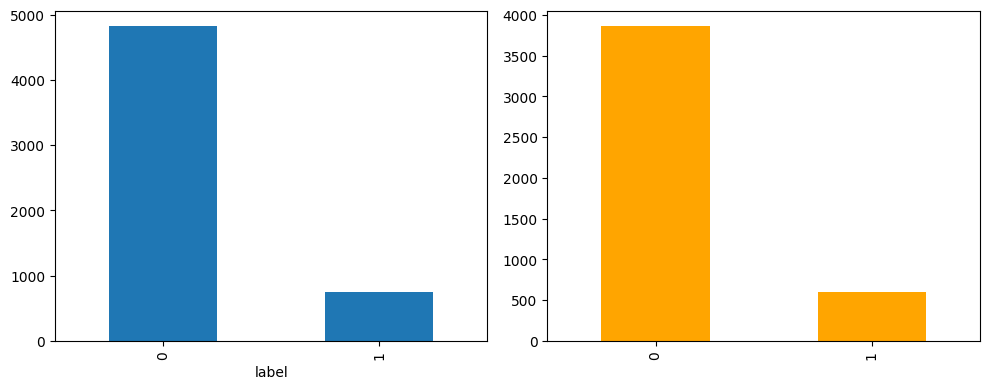

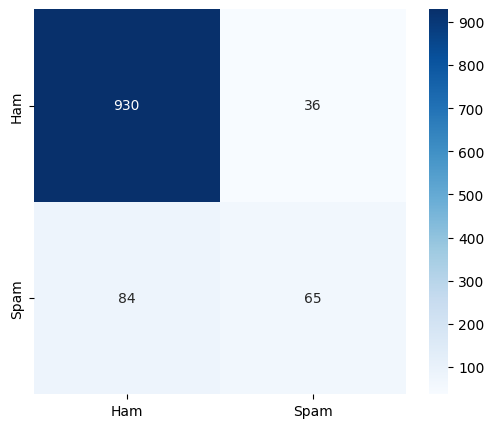

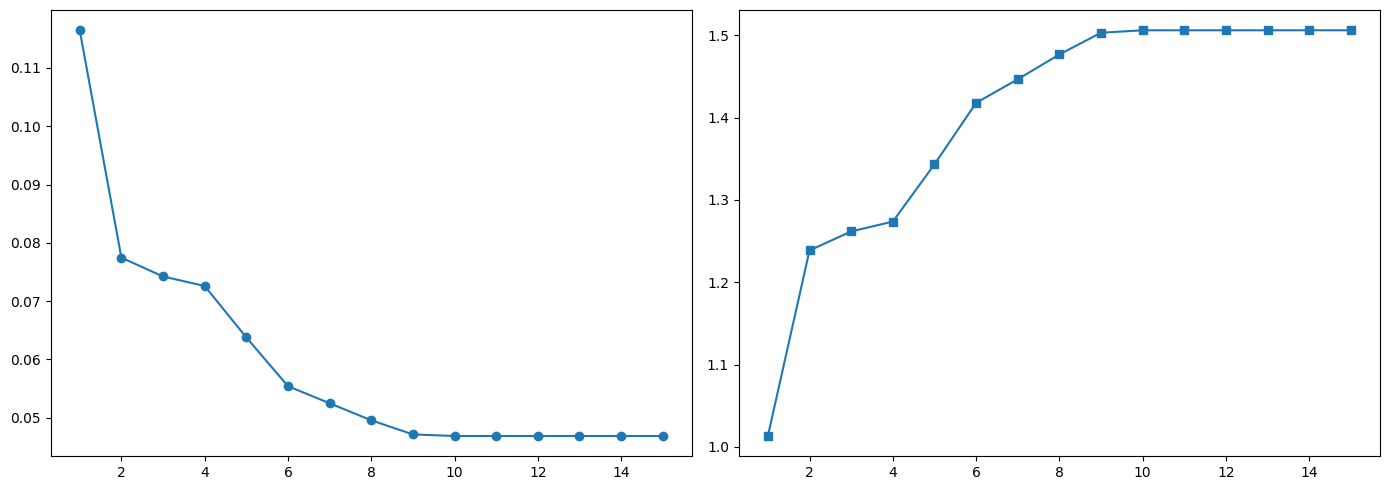

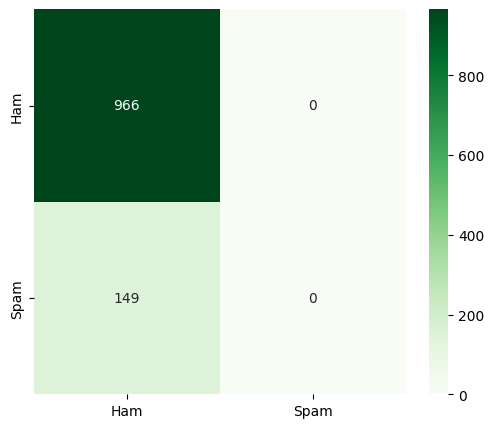

/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


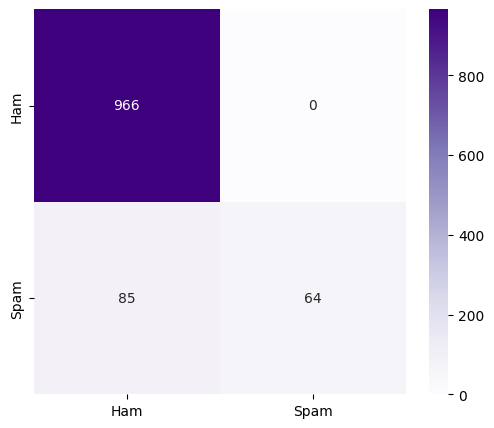

Method               Train Acc    Test Acc    
Decision Stump       0.8836       0.8924      
Manual AdaBoost      0.8658       0.8664      
Sklearn AdaBoost     0.9159       0.9238      


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nltk.download('stopwords')

df = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'msg']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

stopset = set(stopwords.words('english'))

def preprocess(x):
    x = x.lower()
    x = x.translate(str.maketrans('', '', string.punctuation))
    x = ' '.join([i for i in x.split() if i not in stopset])
    return x

df['clean'] = df['msg'].apply(preprocess)

vect = TfidfVectorizer(max_features=3000)
X = vect.fit_transform(df['clean'])
y = df['label'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['label'].value_counts().plot(kind='bar')
plt.subplot(1, 2, 2)
pd.Series(y_tr).value_counts().plot(kind='bar', color='orange')
plt.tight_layout()
plt.show()

base = DecisionTreeClassifier(max_depth=1, random_state=42)
base.fit(X_tr, y_tr)

pred_tr_base = base.predict(X_tr)
pred_te_base = base.predict(X_te)

acc_tr_base = accuracy_score(y_tr, pred_tr_base)
acc_te_base = accuracy_score(y_te, pred_te_base)

cm_b = confusion_matrix(y_te, pred_te_base)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_b, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.show()


class SimpleBoost:
    def __init__(self, rounds=15):
        self.rounds = rounds
        self.alphas = []
        self.models = []
        self.errs = []
        
    def fit(self, X, y):
        n = X.shape[0]
        w = np.ones(n) / n
        
        for _ in range(self.rounds):
            clf = DecisionTreeClassifier(max_depth=1, random_state=42)
            clf.fit(X, y, sample_weight=w)
            pred = clf.predict(X)

            mis = (pred != y)
            err = np.sum(w[mis]) / np.sum(w)
            err = np.clip(err, 1e-10, 1 - 1e-10)
            a = 0.5 * np.log((1 - err) / err)

            w = w * np.exp(-a * y * pred)
            w = w / np.sum(w)

            self.models.append(clf)
            self.alphas.append(a)
            self.errs.append(err)
    
    def predict(self, X):
        all_preds = np.array([m.predict(X) for m in self.models])
        all_preds = 2 * all_preds - 1
        score = np.dot(self.alphas, all_preds)
        return (score > 0).astype(int)


model_manual = SimpleBoost(rounds=15)
model_manual.fit(X_tr, y_tr)

pred_tr_man = model_manual.predict(X_tr)
pred_te_man = model_manual.predict(X_te)

acc_tr_man = accuracy_score(y_tr, pred_tr_man)
acc_te_man = accuracy_score(y_te, pred_te_man)

cm_m = confusion_matrix(y_te, pred_te_man)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(range(1, 16), model_manual.errs, marker='o')
ax[1].plot(range(1, 16), model_manual.alphas, marker='s')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_m, annot=True, cmap='Greens', fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.show()

sk_boost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.6,
    random_state=42,
    algorithm='SAMME'
)

sk_boost.fit(X_tr, y_tr)
pred_tr_sk = sk_boost.predict(X_tr)
pred_te_sk = sk_boost.predict(X_te)

acc_tr_sk = accuracy_score(y_tr, pred_tr_sk)
acc_te_sk = accuracy_score(y_te, pred_te_sk)

cm_sk = confusion_matrix(y_te, pred_te_sk)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_sk, annot=True, cmap='Purples', fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.show()

print(f"{'Method':<20} {'Train Acc':<12} {'Test Acc':<12}")
print(f"{'Decision Stump':<20} {acc_tr_base:<12.4f} {acc_te_base:<12.4f}")
print(f"{'Manual AdaBoost':<20} {acc_tr_man:<12.4f} {acc_te_man:<12.4f}")
print(f"{'Sklearn AdaBoost':<20} {acc_tr_sk:<12.4f} {acc_te_sk:<12.4f}")


### Q2. HEART DISEASE PREDICTION

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
(1025, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
(820, 13)
(205, 13)
0.7695121951219512
0.7219512195121951
[[71 29]
 [28 77]]


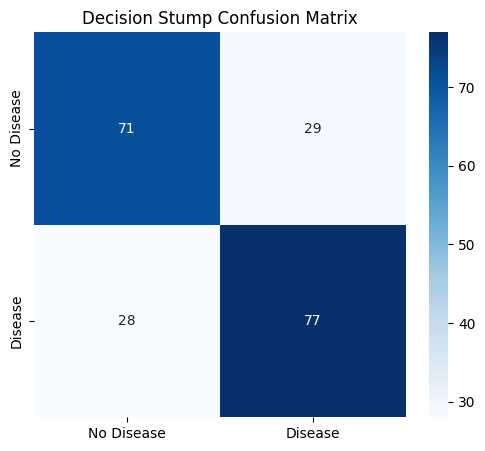

              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71       100
     Disease       0.73      0.73      0.73       105

    accuracy                           0.72       205
   macro avg       0.72      0.72      0.72       205
weighted avg       0.72      0.72      0.72       205

0.1 5 0.7219512195121951
0.1 10 0.775609756097561
0.1 25 0.8439024390243902
0.1 50 0.8292682926829268


/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklea

0.1 100 0.8780487804878049
0.5 5 0.8195121951219512
0.5 10 0.8536585365853658
0.5 25 0.8780487804878049
0.5 50 0.8731707317073171


/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklea

0.5 100 0.8829268292682927
1.0 5 0.8048780487804879
1.0 10 0.8780487804878049
1.0 25 0.8634146341463415
1.0 50 0.8634146341463415
1.0 100 0.8878048780487805


/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklea

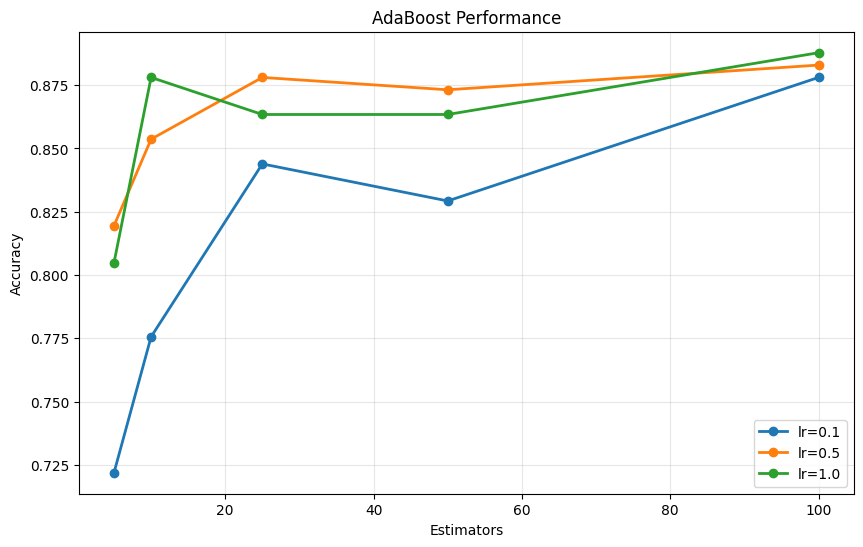

/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklea

{'lr': 1.0, 'n_est': 100, 'model': AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42), 'acc': 0.8878048780487805}


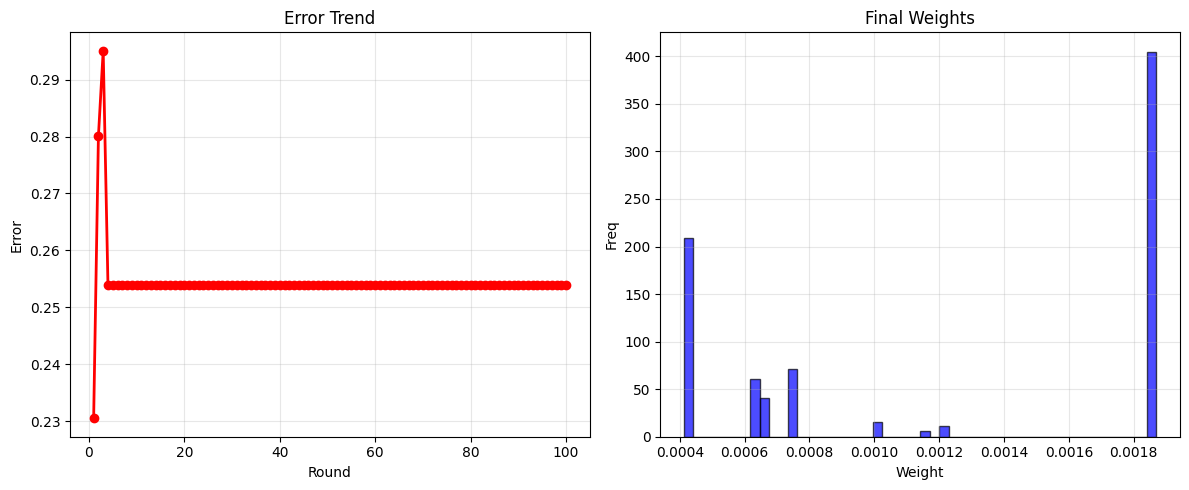

Top weighted samples:
529 0.0018699848002846533
528 0.0018699848002846533
527 0.0018699848002846533
221 0.0018699848002846533
222 0.0018699848002846533
223 0.0018699848002846533
226 0.0018699848002846533
228 0.0018699848002846533
230 0.0018699848002846533
0 0.0018699848002846533

Top features:
1 chol 0.1823138524103944
2 oldpeak 0.17798910695368572
3 thalach 0.15880541576036034
4 age 0.0966862438386843
5 trestbps 0.09546498128423846
6 ca 0.09098494906276836
7 cp 0.06459180455336724
8 thal 0.04551506673607305
9 sex 0.042589868960875875
10 slope 0.0256525728516655


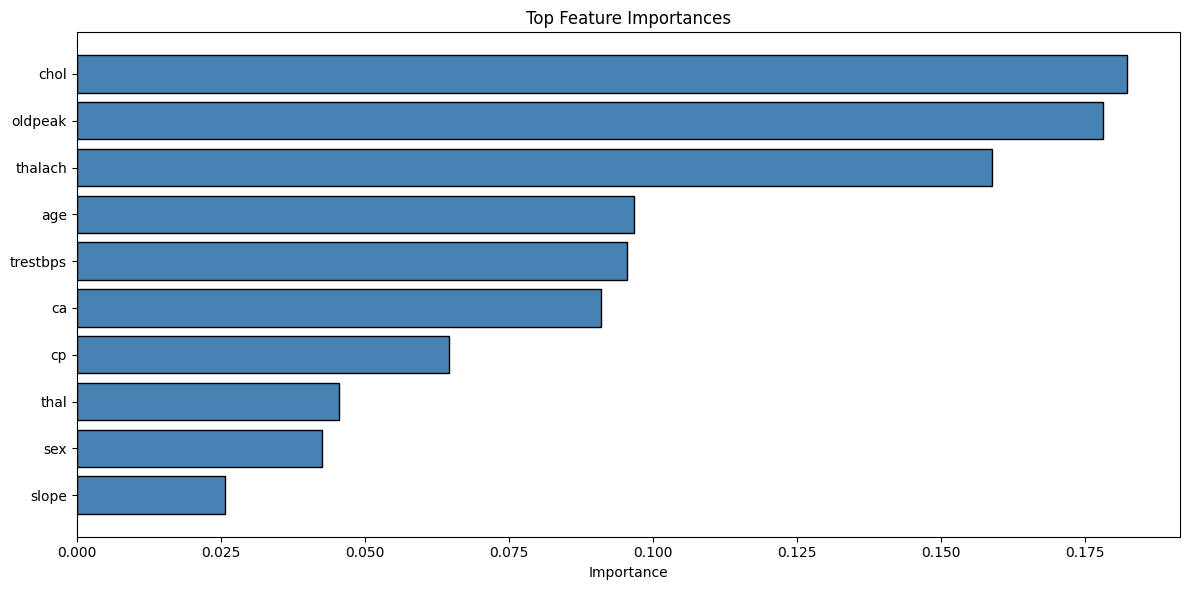

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('heart.csv')
print(df.head())
print(df.shape)
print(df.isnull().sum())

df = df.dropna()

X = df.drop('target', axis=1)
y = (df['target'] > 0).astype(int)

sc = StandardScaler()
X_std = sc.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_std, y, test_size=0.2, random_state=42, stratify=y
)

print(X_tr.shape)
print(X_te.shape)

stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_tr, y_tr)

pred_tr = stump.predict(X_tr)
pred_te = stump.predict(X_te)

acc_tr = accuracy_score(y_tr, pred_tr)
acc_te = accuracy_score(y_te, pred_te)

print(acc_tr)
print(acc_te)

cm = confusion_matrix(y_te, pred_te)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title("Decision Stump Confusion Matrix")
plt.show()

print(classification_report(y_te, pred_te,
                            target_names=['No Disease', 'Disease']))

n_vals = [5, 10, 25, 50, 100]
lr_vals = [0.1, 0.5, 1.0]

results = []

for lr in lr_vals:
    acc_list = []
    for n_est in n_vals:
        clf = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=n_est,
            learning_rate=lr,
            random_state=42,
            algorithm='SAMME'
        )
        clf.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, clf.predict(X_te))
        acc_list.append(acc)
        print(lr, n_est, acc)
    results.append({"lr": lr, "accs": acc_list})

plt.figure(figsize=(10, 6))
for r in results:
    plt.plot(n_vals, r["accs"], marker='o', linewidth=2,
             label=f"lr={r['lr']}")
plt.xlabel("Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_score = 0
best_cfg = {}

for lr in lr_vals:
    for n_est in n_vals:
        temp = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=n_est,
            learning_rate=lr,
            random_state=42,
            algorithm='SAMME'
        )
        temp.fit(X_tr, y_tr)
        s = accuracy_score(y_te, temp.predict(X_te))
        if s > best_score:
            best_score = s
            best_cfg = {'lr': lr, 'n_est': n_est, 'model': temp, 'acc': s}

print(best_cfg)

chosen = best_cfg['model']

class BoostStats:
    def __init__(self, rounds, lr):
        self.rounds = rounds
        self.lr = lr
        self.errors = []
        self.alphas = []
        self.weights = []

    def fit(self, X, y):
        m = len(y)
        w = np.ones(m) / m

        for i in range(self.rounds):
            stump = DecisionTreeClassifier(max_depth=1, random_state=100+i)
            stump.fit(X, y, sample_weight=w)
            p = stump.predict(X)

            wrong = p != y
            e = np.sum(w[wrong]) / np.sum(w)
            e = np.clip(e, 1e-10, 1 - 1e-10)

            a = self.lr * 0.5 * np.log((1 - e) / e)

            self.errors.append(e)
            self.alphas.append(a)
            self.weights.append(w.copy())

            w = w * np.exp(-a * y * p)
            w = w / np.sum(w)

        self.final_w = w
        return self

monitor = BoostStats(best_cfg['n_est'], best_cfg['lr'])
monitor.fit(X_tr, y_tr)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(monitor.errors) + 1), monitor.errors, marker='o',
         linewidth=2, color='red')
plt.xlabel("Round")
plt.ylabel("Error")
plt.grid(alpha=0.3)
plt.title("Error Trend")

plt.subplot(1, 2, 2)
plt.hist(monitor.final_w, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel("Weight")
plt.ylabel("Freq")
plt.grid(alpha=0.3)
plt.title("Final Weights")
plt.tight_layout()
plt.show()

k = 10
final_w = np.asarray(monitor.final_w)      
top_idx = np.argsort(final_w)[-k:]
top_vals = final_w[top_idx]

print("Top weighted samples:")
for i, w in zip(top_idx, top_vals):
    print(i, float(w))
    
imp = chosen.feature_importances_
cols = X.columns
idx_order = np.argsort(imp)[::-1]
topk = min(10, len(cols))

print("\nTop features:")
for i in range(topk):
    j = idx_order[i]
    print(i+1, cols[j], imp[j])

plt.figure(figsize=(12, 6))
plt.barh(range(topk), [imp[i] for i in idx_order[:topk]],
         color='steelblue', edgecolor='black')
plt.yticks(range(topk), [cols[i] for i in idx_order[:topk]])
plt.xlabel("Importance")
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Q3: WISDM MOTION SENSOR ACTIVITY CLASSIFICATION

Dataset shape: (1086466, 6)
   uid      act              ts        ax         ay        az
0   33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1   33  Jogging  49106062271000  5.012288  11.264028  0.953424
2   33  Jogging  49106112167000  4.903325  10.882658 -0.081722
3   33  Jogging  49106222305000 -0.612916  18.496431  3.023717
4   33  Jogging  49106332290000 -1.184970  12.108489  7.205164
act
Walking       418394
Jogging       336445
Upstairs      122869
Downstairs    100425
Sitting        59939
Standing       48394
Name: count, dtype: int64
lbl
0    627151
1    459314
Name: count, dtype: int64
(760525, 3)
(325940, 3)


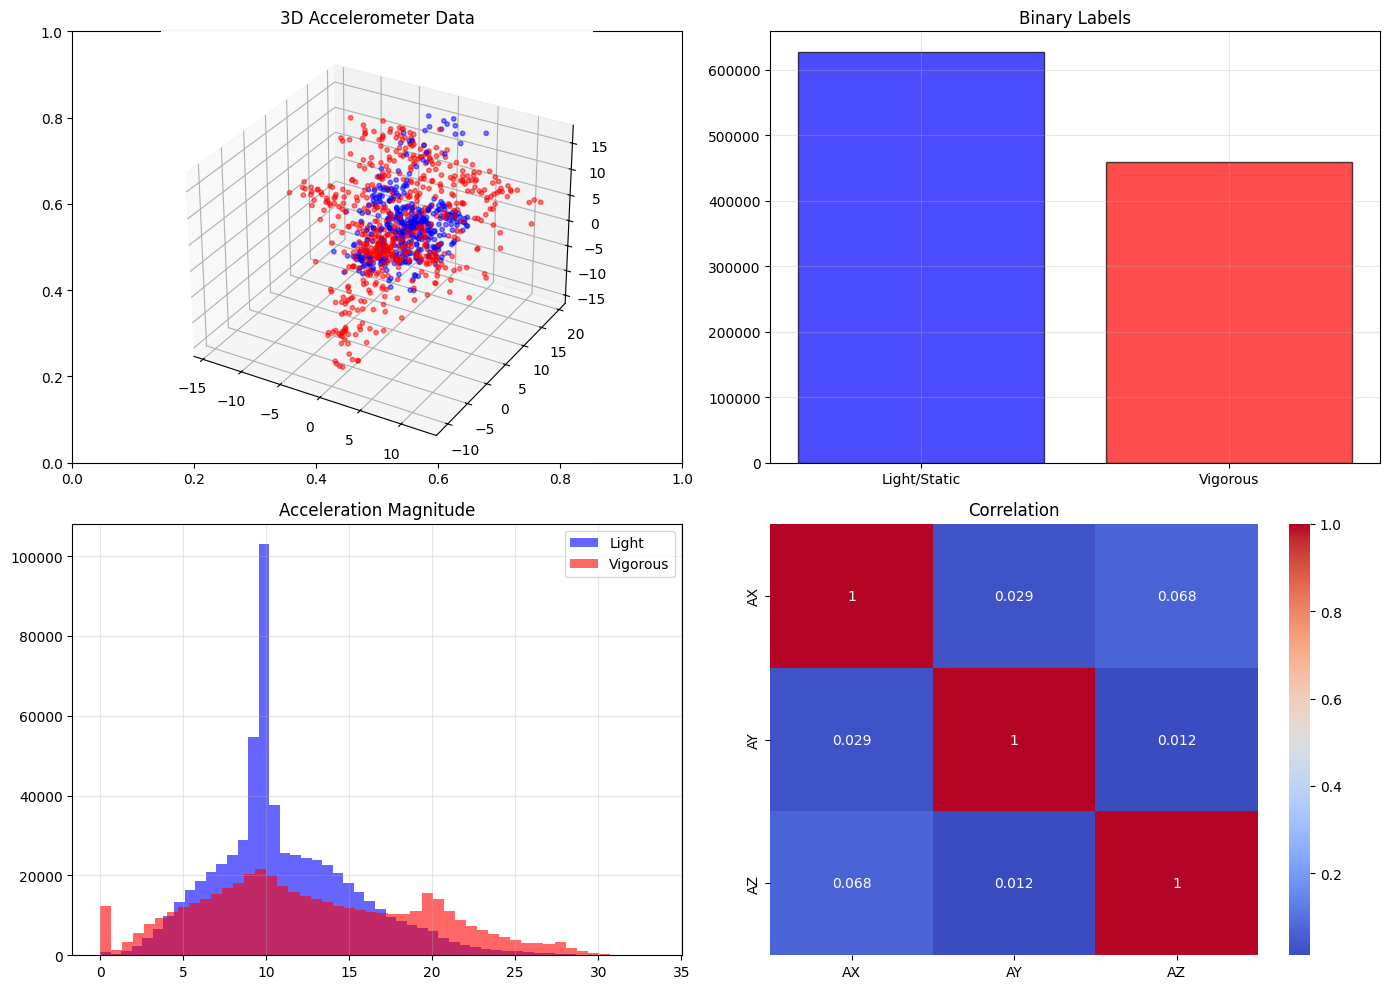

0.6521258341277407
0.6519021905872247
[[170673  17473]
 [ 95986  41808]]


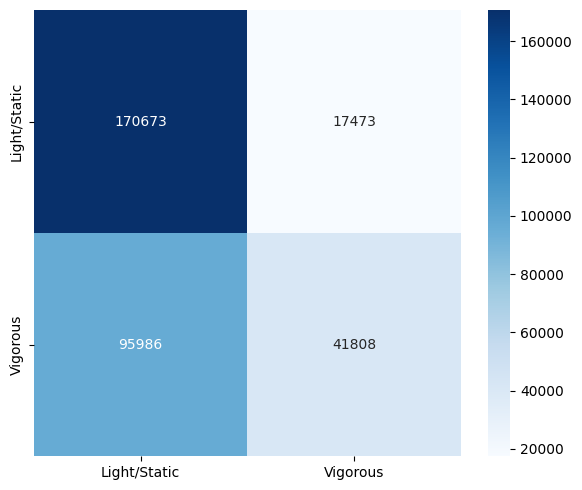

              precision    recall  f1-score   support

           0       0.64      0.91      0.75    188146
           1       0.71      0.30      0.42    137794

    accuracy                           0.65    325940
   macro avg       0.67      0.61      0.59    325940
weighted avg       0.67      0.65      0.61    325940

0.5772394069885934
0.5772412100386575
[[188146      0]
 [137794      0]]


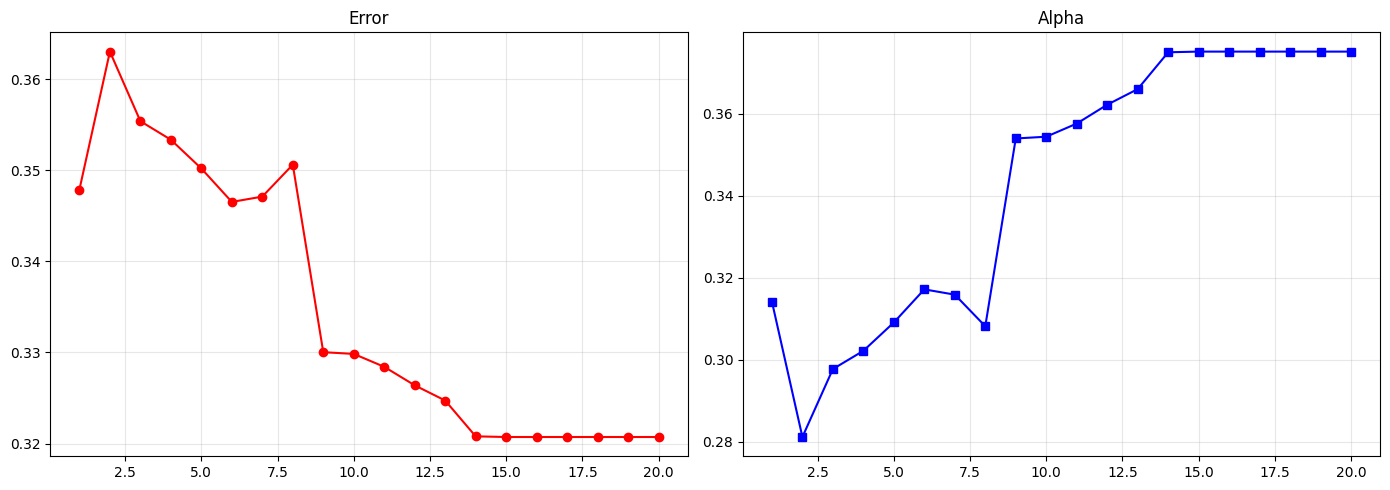

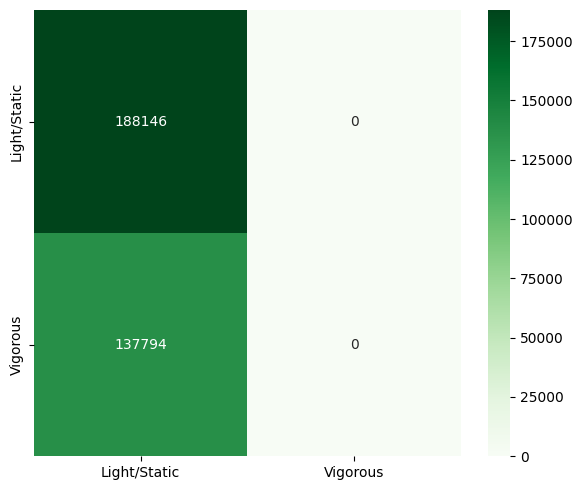

/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/s/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

              precision    recall  f1-score   support

           0       0.58      1.00      0.73    188146
           1       0.00      0.00      0.00    137794

    accuracy                           0.58    325940
   macro avg       0.29      0.50      0.37    325940
weighted avg       0.33      0.58      0.42    325940

0.6976115183590283
0.6969166104190956
[[164210  23936]
 [ 74851  62943]]


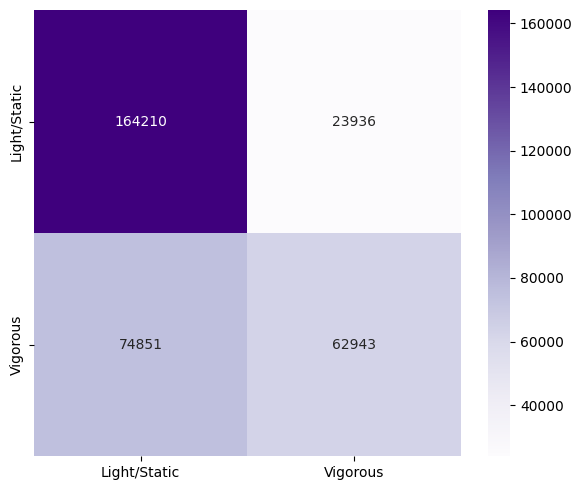

              precision    recall  f1-score   support

           0       0.69      0.87      0.77    188146
           1       0.72      0.46      0.56    137794

    accuracy                           0.70    325940
   macro avg       0.71      0.66      0.66    325940
weighted avg       0.70      0.70      0.68    325940

Method Comparison
Decision Stump: 0.6521 0.6519
Manual Boost: 0.5772 0.5772
Sklearn Boost: 0.6976 0.6969
AX: 0.4069
AY: 0.5327
AZ: 0.0605


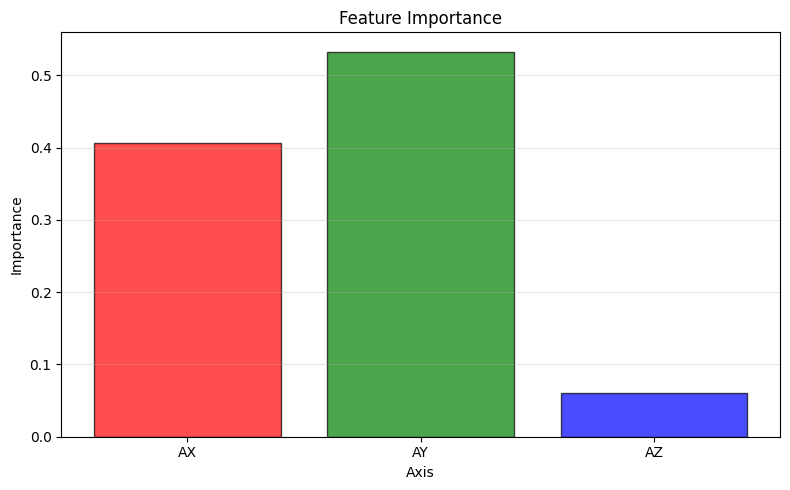

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

col_names = ['uid', 'act', 'ts', 'ax', 'ay', 'az']

raw_df = pd.read_csv(
    "WISDM_ar_v1.1_raw.txt",
    header=None,
    names=col_names,
    on_bad_lines='skip'
)

if raw_df['az'].dtype == object:
    raw_df['az'] = raw_df['az'].str.replace(';', '')
    raw_df['az'] = pd.to_numeric(raw_df['az'], errors='coerce')

print(f"Dataset shape: {raw_df.shape}")
print(raw_df.head())
print(raw_df['act'].value_counts())

raw_df = raw_df.dropna()

def lbl_map(a):
    return 1 if a in ["Jogging", "Upstairs"] else 0

raw_df["lbl"] = raw_df["act"].apply(lbl_map)
print(raw_df["lbl"].value_counts())

X_mat = raw_df[["ax", "ay", "az"]].values
y_vec = raw_df["lbl"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_mat, y_vec, test_size=0.3, random_state=42, stratify=y_vec
)

print(X_tr.shape)
print(X_te.shape)

fig, plots = plt.subplots(2, 2, figsize=(14, 10))
ax3 = fig.add_subplot(2, 2, 1, projection="3d")

samp = min(1000, len(X_mat))
clr = ["red" if l == 1 else "blue" for l in y_vec[:samp]]

ax3.scatter(
    X_mat[:samp, 0],
    X_mat[:samp, 1],
    X_mat[:samp, 2],
    c=clr,
    alpha=0.5,
    s=10
)
ax3.set_title("3D Accelerometer Data")

plots[0, 1].bar(
    ["Light/Static", "Vigorous"],
    raw_df["lbl"].value_counts().sort_index().values,
    color=["blue", "red"],
    alpha=0.7,
    edgecolor="black"
)
plots[0, 1].set_title("Binary Labels")
plots[0, 1].grid(True, alpha=0.3)

acc_mag = np.sqrt(X_mat[:, 0]**2 + X_mat[:, 1]**2 + X_mat[:, 2]**2)
plots[1, 0].hist(acc_mag[y_vec == 0], bins=50, alpha=0.6, label="Light", color="blue")
plots[1, 0].hist(acc_mag[y_vec == 1], bins=50, alpha=0.6, label="Vigorous", color="red")
plots[1, 0].set_title("Acceleration Magnitude")
plots[1, 0].legend()
plots[1, 0].grid(True, alpha=0.3)

corr_df = pd.DataFrame(X_mat, columns=["AX", "AY", "AZ"])
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", ax=plots[1, 1])
plots[1, 1].set_title("Correlation")

plt.tight_layout()
plt.show()

dt_base = DecisionTreeClassifier(max_depth=1, random_state=42)
dt_base.fit(X_tr, y_tr)

pred_tr = dt_base.predict(X_tr)
pred_te = dt_base.predict(X_te)

acc_tr = accuracy_score(y_tr, pred_tr)
acc_te = accuracy_score(y_te, pred_te)

print(acc_tr)
print(acc_te)

cm_d = confusion_matrix(y_te, pred_te)
print(cm_d)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Light/Static', 'Vigorous'],
            yticklabels=['Light/Static', 'Vigorous'])
plt.tight_layout()
plt.show()

print(classification_report(y_te, pred_te))

class SimpleBoost:
    def __init__(self, rounds=20):
        self.rounds = rounds
        self.alpha_list = []
        self.model_list = []
        self.err_list = []
        
    def fit(self, X, y):
        n = len(y)
        w = np.ones(n) / n
        
        for i in range(self.rounds):
            stump = DecisionTreeClassifier(max_depth=1, random_state=100 + i)
            stump.fit(X, y, sample_weight=w)
            p = stump.predict(X)
            
            mis = p != y
            err = np.sum(w[mis]) / np.sum(w)
            err = np.clip(err, 1e-10, 1 - 1e-10)
            
            a = 0.5 * np.log((1 - err) / err)
            w = w * np.exp(-a * y * p)
            w = w / np.sum(w)
            
            self.model_list.append(stump)
            self.alpha_list.append(a)
            self.err_list.append(err)
        
        return self
    
    def predict(self, X):
        preds = np.array([m.predict(X) for m in self.model_list])
        preds = 2 * preds - 1
        weighted = np.dot(self.alpha_list, preds)
        return (weighted > 0).astype(int)

boost_m = SimpleBoost(rounds=20)
boost_m.fit(X_tr, y_tr)

pred_tr_m = boost_m.predict(X_tr)
pred_te_m = boost_m.predict(X_te)

acc_tr_m = accuracy_score(y_tr, pred_tr_m)
acc_te_m = accuracy_score(y_te, pred_te_m)

print(acc_tr_m)
print(acc_te_m)

cm_m = confusion_matrix(y_te, pred_te_m)
print(cm_m)

fig2, axs2 = plt.subplots(1, 2, figsize=(14, 5))
axs2[0].plot(range(1, 21), boost_m.err_list, marker='o', color='red')
axs2[0].set_title("Error")
axs2[0].grid(True, alpha=0.3)

axs2[1].plot(range(1, 21), boost_m.alpha_list, marker='s', color='blue')
axs2[1].set_title("Alpha")
axs2[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Light/Static', 'Vigorous'],
            yticklabels=['Light/Static', 'Vigorous'])
plt.tight_layout()
plt.show()

print(classification_report(y_te, pred_te_m))

sk_boost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42,
    algorithm='SAMME'
)

sk_boost.fit(X_tr, y_tr)

pred_tr_s = sk_boost.predict(X_tr)
pred_te_s = sk_boost.predict(X_te)

acc_tr_s = accuracy_score(y_tr, pred_tr_s)
acc_te_s = accuracy_score(y_te, pred_te_s)

print(acc_tr_s)
print(acc_te_s)

cm_s = confusion_matrix(y_te, pred_te_s)
print(cm_s)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Light/Static', 'Vigorous'],
            yticklabels=['Light/Static', 'Vigorous'])
plt.tight_layout()
plt.show()

print(classification_report(y_te, pred_te_s))

print("Method Comparison")
print(f"Decision Stump: {acc_tr:.4f} {acc_te:.4f}")
print(f"Manual Boost: {acc_tr_m:.4f} {acc_te_m:.4f}")
print(f"Sklearn Boost: {acc_tr_s:.4f} {acc_te_s:.4f}")

axis_lbls = ["AX", "AY", "AZ"]
feat_imp = sk_boost.feature_importances_

for ax, im in zip(axis_lbls, feat_imp):
    print(f"{ax}: {im:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(axis_lbls, feat_imp, color=["red", "green", "blue"],
        alpha=0.7, edgecolor="black")
plt.ylabel("Importance")
plt.xlabel("Axis")
plt.title("Feature Importance")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
